In [ ]:
#Prove integral with decay 210-Po#
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, simpson, dblquad
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.optimize import brentq

Z_alpha=2
Z_daugther=82
e2=1.44
a_0=0.54
alpha=0.7024
beta=0.22
A_alpha=4
A_daugther=206
x=7999/4
y=2134/2.5
R_0=1.07*(A_daugther)**(1/3)
beta2 = 0.0
beta4 = 0.008
J00=-275
Q_alpha = 5.407
hbarc = 197.327
L = 0
G = 18
B = (G - L + 1) * (np.pi / 2)
m_n = 931.5
muc2=(A_daugther*A_alpha)/(A_daugther+A_alpha)*m_n
zpb=(muc2*(beta)**2)/(2*(hbarc)**2)

#----------------------CONSTRUCCION DE POTENCIAL NUCLEAR--------------------------------------------------

#Normalizacion del valor del valor la densidad de la hija
def Y00(theta):
    return np.sqrt(1/(4*np.pi))
def Y20(theta):
    return (1/4)*(np.sqrt(5/np.pi))*(3*(np.cos(theta))**2-1)
def Y40(theta):
    return (3/16) * (np.sqrt(1/np.pi)) * (35*(np.cos(theta))**4-30*(np.cos(theta))**2+3)

def R_f_theta(theta):    
    return R_0*(1+beta2*Y20(theta)+beta4*Y40(theta))

def a_f_theta(theta):
    a_perpendicular=a_0*(1+beta2*Y20(theta)+beta4*Y40(theta))
    gradR=(R_0/R_f_theta(theta))*(-(3/2)*(np.sqrt(5/np.pi))*beta2*np.cos(theta)*np.sin(theta)
                           -(105/4)*(np.sqrt(1/np.pi))*beta4*
                           (np.cos(theta))**3*np.sin(theta)+(45/4)*(np.sqrt(1/np.pi))*beta4
                           *np.cos(theta)*np.sin(theta))
    return a_perpendicular*(np.sqrt(1+(np.abs(gradR)**2)))
#Normalizacion  
def rho2(theta,r):    
    argumento=1/ (1+np.exp((r-R_f_theta(theta))/(a_f_theta(theta))))
    return argumento*r**2*np.sin(theta)
I_rho2=dblquad(rho2, 0.01 , 15, lambda r:0, lambda r: np.pi)
rho2_normalizado=A_daugther/(2*np.pi*I_rho2[0])


#------------FURIER TRASNFORM----------------------

#Mine Values
rmalla = np.linspace(0.01, 25, 500)
theta=np.linspace(0,np.pi,250)
r2, Theta = np.meshgrid(rmalla, theta, indexing='ij')
k = np.linspace(0.001, 25, 400)

####---------------Bessel Funtion------------

def j0(r2,k):
    return (np.sin(k*r2))/(k*r2)

def j2(r2,k):
    x = k*r2
    return ((3/(x)**2)-1)*((np.sin(x))/(x))-3*((np.cos(x))/(x)**2)

def j4(r2,k):
    x = k*r2
    return (((105)/(x)**5)-((45)/(x)**3)+(1/(x)))*np.sin(x)-(((105)/(x)**4)-((10)/(x)**2))*np.cos(x)


rho2_furiernuclear0=[]
for ki in k:
    rho2_integral0=2*np.pi*rho2_normalizado*j0(r2,ki)*Y00(Theta)*r2**2*np.sin(Theta)*(1/(1+np.exp((r2-R_f_theta(Theta))/(a_f_theta(Theta)))))
    integral_r0 = simpson(rho2_integral0, x=rmalla, axis=0)   
    integral_completa0 = simpson(integral_r0, x=theta)      
    rho2_furiernuclear0.append(integral_completa0)    
rho2_fnuclear0=np.array(rho2_furiernuclear0)



rho2_furiernuclear2=[]
for ki in k:
    rho2_integral2=2*np.pi*rho2_normalizado*j2(r2,ki)*Y20(Theta)*r2**2*np.sin(Theta)*(1/(1+np.exp((r2-R_f_theta(Theta))/(a_f_theta(Theta)))))
    integral_r2 = simpson(rho2_integral2, x=rmalla, axis=0)   
    integral_completa2 = simpson(integral_r2, x=theta)      
    rho2_furiernuclear2.append(integral_completa2)    
rho2_fnuclear2=np.array(rho2_furiernuclear2)


rho2_furiernuclear4=[]
for ki in k:
    rho2_integral4=2*np.pi*rho2_normalizado*j4(r2,ki)*Y40(Theta)*r2**2*np.sin(Theta)*(1/(1+np.exp((r2-R_f_theta(Theta))/(a_f_theta(Theta)))))
    integral_r4 = simpson(rho2_integral4, x=rmalla, axis=0)   
    integral_completa4 = simpson(integral_r4, x=theta)      
    rho2_furiernuclear4.append(integral_completa4)    
rho2_fnuclear4=np.array(rho2_furiernuclear4)




#Ahora de la particula alfa, que será la esferica 
rho1_furiernuclear=0.4228*(np.pi/alpha)**(1.5)*np.exp(-k**2/(4*alpha))

#Transformada del potencial nuclear

R=np.linspace(0.05,30,800)
phi = np.linspace(0, np.pi, 600)

def j0N(R,k):
    return (np.sin(k*R))/(k*R)

def j2N(R,k):
    x = k*R
    return ((3/(x)**2)-1)*((np.sin(x))/(x))-3*((np.cos(x))/(x)**2)

def j4N(R,k):
    x = k*R
    return (((105)/(x)**5)-((45)/(x)**3)+(1/(x)))*np.sin(x)-(((105)/(x)**4)-((10)/(x)**2))*np.cos(x)

#L=0
V_NN0=[]
for Ri in R:
    g=(x/((k**2)+4**2))-(y/((k**2)+(2.5)**2))# + J00/(4*np.pi)
    V_Fold0 =(2/np.pi) *((1)/(np.sqrt(4*np.pi)))* rho1_furiernuclear * rho2_fnuclear0 *j0N(Ri,k)*k**2*(4*np.pi*g)
    V_NN0.append(simpson(V_Fold0,k))
V_NN0=np.array(V_NN0)

#L=2
def P2(phi):
    return 0.5*(3*np.cos(phi)**2 - 1)


V_NN2=[]
for Ri in R:
    g=(x/((k**2)+4**2))-(y/((k**2)+(2.5)**2))# + J00/(4*np.pi)
    V_Fold2 =(2/np.pi)*np.sqrt((5/(4*np.pi))) * rho1_furiernuclear * rho2_fnuclear2 *j2N(Ri,k)*k**2*(4*np.pi*g)
    V_NN2.append(simpson(V_Fold2,k))
V_NN2=np.array(V_NN2)


V2_NN = V_NN2[:, None] * P2(phi)[None, :]
#L=4
def P4(phi):
    return (1/8)*(35*(np.cos(phi))**4 -30*(np.cos(phi))**2+3)


V_NN4=[]
for Ri in R:
    g=(x/((k**2)+4**2))-(y/((k**2)+(2.5)**2))# + J00/(4*np.pi)
    V_Fold4 =(2/np.pi)*np.sqrt((9/(4*np.pi))) * rho1_furiernuclear * rho2_fnuclear4 *j4N(Ri,k)*k**2*(4*np.pi*g)
    V_NN4.append(simpson(V_Fold4,k))
V_NN4=np.array(V_NN4)


V4_NN = V_NN4[:, None] * P4(phi)[None, :]

#print(V_NN)
V_Nuclear=V_NN0[:, None]+V2_NN+V4_NN



#Construccion de potencial de Coulomb el cual tambien dependera del radio y del ángulo 
#normalizacion de carga alfa
def I1(r1):
    I_rho_alphacoulomb=r1**2*np.exp(-alpha*r1**2)
    return I_rho_alphacoulomb
I_solve1=quad(I1, 0, 15)
rho1_normalizadocoulomb=(Z_alpha)/(4*np.pi*I_solve1[0])

#normalizacion de carga Z=82


def rho2coulomb(theta,r):    
    argumento=1/ (1+np.exp((r-R_f_theta(theta))/(a_f_theta(theta))))
    return argumento*r**2*np.sin(theta)
I_rho2=dblquad(rho2coulomb, 0.01 , 15, lambda r:0, lambda r: np.pi)
rho2_normalizadocoulomb=Z_daugther/(2*np.pi*I_rho2[0])

#Fourier Transform alfa
rho1_furiercoulomb=rho1_normalizadocoulomb*(np.pi/alpha)**(1.5)*np.exp(-k**2/(4*alpha))

rho2_furiercoulomb0=[]
for ki in k:
    rho2_integral0coulomb=2*np.pi*rho2_normalizadocoulomb*j0(r2,ki)*Y00(Theta)*r2**2*np.sin(Theta)*(1/(1+np.exp((r2-R_f_theta(Theta))/(a_f_theta(Theta)))))
    integral_r0coulomb = simpson(rho2_integral0coulomb, x=rmalla, axis=0)   
    integral_completa0coulomb = simpson(integral_r0coulomb, x=theta)      
    rho2_furiercoulomb0.append(integral_completa0coulomb)    
rho2_fcoulomb0=np.array(rho2_furiercoulomb0)



rho2_furiercoulomb2=[]
for ki in k:
    rho2_integral2coulomb=2*np.pi*rho2_normalizadocoulomb*j2(r2,ki)*Y20(Theta)*r2**2*np.sin(Theta)*(1/(1+np.exp((r2-R_f_theta(Theta))/(a_f_theta(Theta)))))
    integral_r2coulomb = simpson(rho2_integral2coulomb, x=rmalla, axis=0)   
    integral_completa2coulomb = simpson(integral_r2coulomb, x=theta)      
    rho2_furiercoulomb2.append(integral_completa2coulomb)    
rho2_fcoulomb2=np.array(rho2_furiercoulomb2)


rho2_furiercoulomb4=[]
for ki in k:
    rho2_integral4coulomb=2*np.pi*rho2_normalizadocoulomb*j4(r2,ki)*Y40(Theta)*r2**2*np.sin(Theta)*(1/(1+np.exp((r2-R_f_theta(Theta))/(a_f_theta(Theta)))))
    integral_r4coulomb = simpson(rho2_integral4coulomb, x=rmalla, axis=0)   
    integral_completa4coulomb = simpson(integral_r4coulomb, x=theta)      
    rho2_furiercoulomb4.append(integral_completa4coulomb)    
rho2_fcoulomb4=np.array(rho2_furiercoulomb4)

#--------------Potencial trasnformado-----------------------
#L=0
V_C0=[]
for Ri in R:
    V_Fold = (2*e2/np.pi) *((4*np.pi)/np.sqrt(4*np.pi))* rho1_furiercoulomb * rho2_fcoulomb0 * j0N(Ri,k)
    V_C0.append(simpson(V_Fold,k))
V0_C=np.array(V_C0)
#L=2
V_C2=[]
for Ri in R:
    V_Fold2 = (2*e2/np.pi)*4*np.pi *np.sqrt((5)/(4*np.pi))* rho1_furiercoulomb * rho2_fcoulomb2 * j2N(Ri,k)
    V_C2.append(simpson(V_Fold2,k))
V_C2=np.array(V_C2)

V2_C = V_C2[:, None] * P2(phi)[None, :]
#L=4
V_C4=[]
for Ri in R:
    V_Fold4 = (2*e2/np.pi) *4*np.pi*(np.sqrt((9)/(4*np.pi))) *rho1_furiercoulomb * rho2_fcoulomb4 * j4N(Ri,k)
    V_C4.append(simpson(V_Fold4,k))
V_C4=np.array(V_C4)

V4_C = V_C4[:, None] * P4(phi)[None, :]

V_Coulomb=V0_C[:,None]+V2_C+V4_C


#Centrifuco
V_L  = (hbarc**2 / (2 * muc2)) * ((L + 0.5)**2 /( R**2))

def action(lam):
    for V_Coulombi, V_Li, V_Nucleari in zip(V_Coulomb, V_L, V_Nuclear):
        V=lam*V_Nucleari + V_Coulombi + V_Li
        s=InterpolatedUnivariateSpline(R, Q_alpha - V, k=3)
        roots=s.roots()
        if len(roots)<2:
            return None
        r1, r2 = roots[0], roots[1]
        f= lambda r: np.sqrt((2*muc2/hbarc**2)*s(r))
        return quad(f, r1, r2, limit=200)[0]
        
lamdas = np.linspace(0.5, 3, 3000)
vals = [(lam, action(lam)) for lam in lamdas]
#vals = [(l,I) for l,I in vals if I is not None]

lam_opt = min(vals, key=lambda x: abs(x[1]-B))[0]
print("lambda =", np.round(lam_opt,3))
        


φ =    0.0°  →  λ = 2.0889
φ =    5.0°  →  λ = 2.0893
φ =   10.0°  →  λ = 2.0902
φ =   15.0°  →  λ = 2.0916
φ =   20.0°  →  λ = 2.0934
φ =   25.0°  →  λ = 2.0953
φ =   30.0°  →  λ = 2.0972
φ =   35.0°  →  λ = 2.0989
φ =   40.0°  →  λ = 2.1001
φ =   45.0°  →  λ = 2.1009
φ =   50.0°  →  λ = 2.1010
φ =   55.0°  →  λ = 2.1007
φ =   60.0°  →  λ = 2.0999
φ =   65.0°  →  λ = 2.0987
φ =   70.0°  →  λ = 2.0975
φ =   75.0°  →  λ = 2.0962
φ =   80.0°  →  λ = 2.0952
φ =   85.0°  →  λ = 2.0945
φ =   90.0°  →  λ = 2.0942
φ =   95.0°  →  λ = 2.0945
φ =  100.0°  →  λ = 2.0952
φ =  105.0°  →  λ = 2.0962
φ =  110.0°  →  λ = 2.0975
φ =  115.0°  →  λ = 2.0987
φ =  120.0°  →  λ = 2.0999
φ =  125.0°  →  λ = 2.1007
φ =  130.0°  →  λ = 2.1010
φ =  135.0°  →  λ = 2.1009
φ =  140.0°  →  λ = 2.1001
φ =  145.0°  →  λ = 2.0989
φ =  150.0°  →  λ = 2.0972
φ =  155.0°  →  λ = 2.0953
φ =  160.0°  →  λ = 2.0934
φ =  165.0°  →  λ = 2.0916
φ =  170.0°  →  λ = 2.0902
φ =  175.0°  →  λ = 2.0893
φ =  180.0°  →  λ = 2.0889


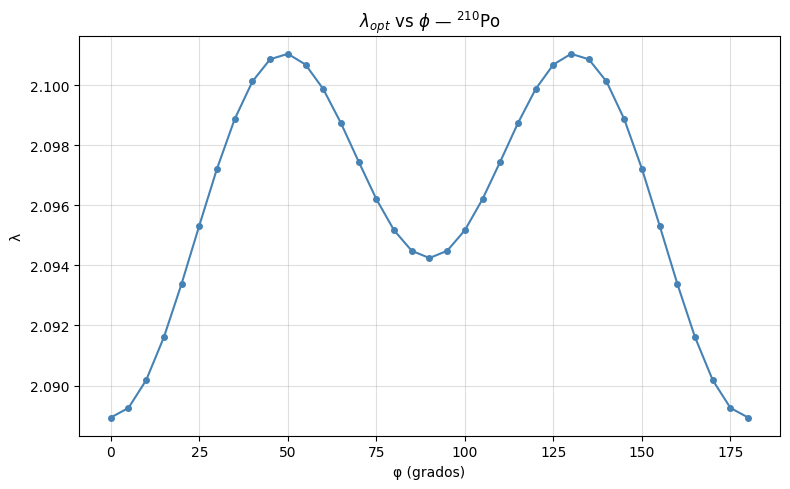

'\n\ndef action_phi(lam, phi_idx):\n    V_total = lam * V_Nuclear[:, phi_idx] + V_Coulomb[:, phi_idx] + V_L\n\n    s = InterpolatedUnivariateSpline(R, Q_alpha - V_total, k=3)\n    roots = s.roots()\n\n    if len(roots) < 2:\n        return None\n\n    r1, r2 = roots[0], roots[-1]\n    f = lambda r: np.sqrt(np.abs((2 * muc2 / hbarc**2) * s(r)))\n    return quad(f, r1, r2, limit=200)[0]\n\n\nlamdas = np.linspace(0.5, 3, 3000)\nlam_opt_vs_phi = []\n\nfor i, ph in enumerate(phi):\n    vals = [(lam, action_phi(lam, i)) for lam in lamdas]\n    vals = [(l, I) for l, I in vals if I is not None]\n\n    if vals:\n        lam_opt_i = min(vals, key=lambda x: abs(x[1] - B))[0]\n        lam_opt_vs_phi.append((ph, lam_opt_i))\n        print(f"φ = {np.degrees(ph):.1f}°  →  lambda = {lam_opt_i:.4f}")\n    else:\n        lam_opt_vs_phi.append((ph, None))\n        print(f"φ = {np.degrees(ph):.1f}°  →  sin solución")\n\nphi_vals   = np.array([p   for p, l in lam_opt_vs_phi if l is not None])\nlam_vals   =

In [13]:
# Prove integral with decay 210-Po — VERSION VECTORIZADA
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, simpson, dblquad
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.optimize import brentq

# ─── Constantes ───────────────────────────────────────────────────────────────
Z_alpha    = 2
Z_daugther = 82
e2         = 1.44
a_0        = 0.54
alpha      = 0.7024
beta       = 0.22
A_alpha    = 4
A_daugther = 206
x          = 7999 / 4
y          = 2134 / 2.5
R_0        = 1.07 * (A_daugther) ** (1 / 3)
beta2      = 0.0
beta4      = 0.008
J00        = -275
Q_alpha    = 5.407
hbarc      = 197.327
L          = 0
G          = 22
B          = (G - L + 1) * (np.pi / 2)
m_n        = 931.5
muc2       = (A_daugther * A_alpha) / (A_daugther + A_alpha) * m_n
zpb        = (muc2 * (beta) ** 2) / (2 * (hbarc) ** 2)

# ─── Armónicos esféricos y geometría de la hija ──────────────────────────────
def Y00(theta): return np.sqrt(1 / (4 * np.pi))
def Y20(theta): return (1 / 4) * np.sqrt(5 / np.pi) * (3 * np.cos(theta) ** 2 - 1)
def Y40(theta): return (3 / 16) * np.sqrt(1 / np.pi) * (35 * np.cos(theta) ** 4 - 30 * np.cos(theta) ** 2 + 3)

def R_f_theta(theta):
    return R_0 * (1 + beta2 * Y20(theta) + beta4 * Y40(theta))

def a_f_theta(theta):
    a_perp = a_0 * (1 + beta2 * Y20(theta) + beta4 * Y40(theta))
    gradR  = (R_0 / R_f_theta(theta)) * (
        -(3 / 2) * np.sqrt(5 / np.pi) * beta2 * np.cos(theta) * np.sin(theta)
        - (105 / 4) * np.sqrt(1 / np.pi) * beta4 * np.cos(theta) ** 3 * np.sin(theta)
        + (45  / 4) * np.sqrt(1 / np.pi) * beta4 * np.cos(theta) * np.sin(theta)
    )
    return a_perp * np.sqrt(1 + np.abs(gradR) ** 2)

# ─── Grillas ─────────────────────────────────────────────────────────────────
rmalla = np.linspace(0.01, 25, 500)
theta  = np.linspace(0, np.pi, 250)
r2, Theta = np.meshgrid(rmalla, theta, indexing='ij')   # (r, θ)

k = np.linspace(0.001, 25, 400)
R = np.linspace(0.05, 30, 800)
phi = np.linspace(0, np.pi, 37)

# Densidad de Fermi (grilla r×θ) — calculada una sola vez
fermi_2D = 1.0 / (1.0 + np.exp((r2 - R_f_theta(Theta)) / a_f_theta(Theta)))

# ─── Funciones de Bessel esféricas ───────────────────────────────────────────
# Versión vectorizada (soporta arrays 2-D)
def j0_f(x): return np.sin(x) / x
def j2_f(x): return (3 / x**2 - 1) * np.sin(x) / x - 3 * np.cos(x) / x**2
def j4_f(x): return ((105 / x**5) - (45 / x**3) + (1 / x)) * np.sin(x) - ((105 / x**4) - (10 / x**2)) * np.cos(x)

# ─── Normalización densidad nuclear hija ─────────────────────────────────────
def rho2_integrand(theta, r):
    return (1 / (1 + np.exp((r - R_f_theta(theta)) / a_f_theta(theta)))) * r**2 * np.sin(theta)

I_rho2, _ = dblquad(rho2_integrand, 0.01, 15, 0, np.pi)
rho2_norm        = A_daugther / (2 * np.pi * I_rho2)
rho2_norm_coulomb = Z_daugther / (2 * np.pi * I_rho2)   # misma integral geométrica

# ─── Transformadas de Fourier de ρ₂ (vectorizadas) ──────────────────────────
# Grilla para la integración: r(eje 0), θ(eje 1), k(eje 2)
# Se construye una vez y se usa para los seis momentos (L=0,2,4 × nuclear/Coulomb)

r3   = rmalla[:, None, None]          # (r, 1, 1)
Th3  = theta[None, :, None]           # (1, θ, 1)
k3   = k[None, None, :]              # (1, 1, k)

fermi_3D = 1.0 / (1.0 + np.exp((r3 - R_f_theta(Th3)) / a_f_theta(Th3)))
sin_Th   = np.sin(Th3)

def fourier_rho2(norm, Ylm, jl, factor_4pi):
    """
    Calcula ∫∫ 2π · norm · jl(kr) · Ylm(θ) · ρ₂(r,θ) · r² sinθ dr dθ  para cada k.
    Retorna array de forma (len(k),).
    """
    # integrand shape: (r, θ, k)
    integrand = 2 * np.pi * norm * jl(r3 * k3) * Ylm(Th3) * r3**2 * sin_Th * fermi_3D
    int_r  = simpson(integrand, x=rmalla, axis=0)   # (θ, k)
    return simpson(int_r, x=theta, axis=0)           # (k,)

# jl evaluados sobre la grilla r×k
rho2_fn0 = fourier_rho2(rho2_norm,         Y00, j0_f, 1)
rho2_fn2 = fourier_rho2(rho2_norm,         Y20, j2_f, 1)
rho2_fn4 = fourier_rho2(rho2_norm,         Y40, j4_f, 1)

rho2_fc0 = fourier_rho2(rho2_norm_coulomb, Y00, j0_f, 1)
rho2_fc2 = fourier_rho2(rho2_norm_coulomb, Y20, j2_f, 1)
rho2_fc4 = fourier_rho2(rho2_norm_coulomb, Y40, j4_f, 1)

# ─── Transformadas de Fourier de ρ₁ (alfa — analíticas) ─────────────────────
I_r1, _         = quad(lambda r1: r1**2 * np.exp(-alpha * r1**2), 0, 15)
rho1_norm_c     = Z_alpha / (4 * np.pi * I_r1)
gauss_k         = np.exp(-k**2 / (4 * alpha))

rho1_fn = 0.4228 * (np.pi / alpha) ** 1.5 * gauss_k                       # nuclear
rho1_fc = rho1_norm_c * (np.pi / alpha) ** 1.5 * gauss_k                  # Coulomb

# ─── Potencial nuclear — integración en k vectorizada ────────────────────────
# V(R) = (2/π) · prefactor · ∫ ρ₁(k)·ρ₂L(k)·jL(kR)·k²·g(k) dk
# Grilla R×k:
Rm, km = np.meshgrid(R, k, indexing='ij')   # (R, k)
g_k    = x / (k**2 + 4**2) - y / (k**2 + 2.5**2)

def V_nuclear_L(rho1, rho2_fL, jLN, prefactor):
    integrand = prefactor * rho1[None, :] * rho2_fL[None, :] * jLN(Rm * km) * km**2 * (4 * np.pi * g_k[None, :])
    return (2 / np.pi) * simpson(integrand, x=k, axis=1)   # (R,)

V_NN0 = V_nuclear_L(rho1_fn, rho2_fn0, j0_f, 1 / np.sqrt(4 * np.pi))
V_NN2 = V_nuclear_L(rho1_fn, rho2_fn2, j2_f, np.sqrt(5 / (4 * np.pi)))
V_NN4 = V_nuclear_L(rho1_fn, rho2_fn4, j4_f, np.sqrt(9 / (4 * np.pi)))

# ─── Potencial Coulomb — integración en k vectorizada ────────────────────────
def V_coulomb_L(rho1, rho2_fL, jLN, prefactor):
    integrand = prefactor * rho1[None, :] * rho2_fL[None, :] * jLN(Rm * km)
    return (2 * e2 / np.pi) * simpson(integrand, x=k, axis=1)

V_C0 = V_coulomb_L(rho1_fc, rho2_fc0, j0_f, 4 * np.pi / np.sqrt(4 * np.pi))
V_C2 = V_coulomb_L(rho1_fc, rho2_fc2, j2_f, 4 * np.pi * np.sqrt(5  / (4 * np.pi)))
V_C4 = V_coulomb_L(rho1_fc, rho2_fc4, j4_f, 4 * np.pi * np.sqrt(9  / (4 * np.pi)))

# ─── Polinomios de Legendre y ensamble final ──────────────────────────────────
def P2(phi): return 0.5 * (3 * np.cos(phi)**2 - 1)
def P4(phi): return (1 / 8) * (35 * np.cos(phi)**4 - 30 * np.cos(phi)**2 + 3)

# Potencial nuclear total: (R, φ)
V_Nuclear = (
    V_NN0[:, None]
    + V_NN2[:, None] * P2(phi)[None, :]
    + V_NN4[:, None] * P4(phi)[None, :]
)

# Potencial Coulomb total: (R, φ)
V_Coulomb = (
    V_C0[:, None]
    + V_C2[:, None] * P2(phi)[None, :]
    + V_C4[:, None] * P4(phi)[None, :]
)

# ─── Potencial centrífugo ─────────────────────────────────────────────────────
V_L = (hbarc**2 / (2 * muc2)) * ((L + 0.5)**2 / R**2)

def accion_phi_lam(lam, phi_idx):
    V_total = lam * V_Nuclear[:, phi_idx] + V_Coulomb[:, phi_idx] + V_L
    s = InterpolatedUnivariateSpline(R, Q_alpha - V_total, k=3)
    roots = s.roots()
    if len(roots) < 2:
        return None
    r1, r2 = roots[0], roots[-1]
    f = lambda r: np.sqrt(np.abs((2 * muc2 / hbarc**2) * s(r)))
    return quad(f, r1, r2, limit=200)[0]

lam_opt_vs_phi = []

for i, ph in enumerate(phi):
    try:
        # brentq encuentra el lambda donde S(λ) - B = 0
        lam_opt_i = brentq(
            lambda lam: accion_phi_lam(lam, i) - B,
            a=0.5, b=3.0,
            xtol=1e-4
        )
        lam_opt_vs_phi.append((ph, lam_opt_i))
        print(f"φ = {np.degrees(ph):6.1f}°  →  λ = {lam_opt_i:.4f}")
    except (ValueError, TypeError):
        lam_opt_vs_phi.append((ph, None))
        print(f"φ = {np.degrees(ph):6.1f}°  →  sin solución")


phi_arr = np.array([p for p, l in lam_opt_vs_phi if l is not None])
lam_arr = np.array([l for p, l in lam_opt_vs_phi if l is not None])

plt.figure(figsize=(8, 5))
plt.plot(np.degrees(phi_arr), lam_arr, 'o-', markersize=4, color='steelblue')
plt.xlabel("φ (grados)")
plt.ylabel("λ")
plt.title(r"$\lambda_{opt}$ vs $\phi$ — $^{210}$Po")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
'''

def action_phi(lam, phi_idx):
    V_total = lam * V_Nuclear[:, phi_idx] + V_Coulomb[:, phi_idx] + V_L
    
    s = InterpolatedUnivariateSpline(R, Q_alpha - V_total, k=3)
    roots = s.roots()
    
    if len(roots) < 2:
        return None
    
    r1, r2 = roots[0], roots[-1]
    f = lambda r: np.sqrt(np.abs((2 * muc2 / hbarc**2) * s(r)))
    return quad(f, r1, r2, limit=200)[0]


lamdas = np.linspace(0.5, 3, 3000)
lam_opt_vs_phi = []

for i, ph in enumerate(phi):
    vals = [(lam, action_phi(lam, i)) for lam in lamdas]
    vals = [(l, I) for l, I in vals if I is not None]
    
    if vals:
        lam_opt_i = min(vals, key=lambda x: abs(x[1] - B))[0]
        lam_opt_vs_phi.append((ph, lam_opt_i))
        print(f"φ = {np.degrees(ph):.1f}°  →  lambda = {lam_opt_i:.4f}")
    else:
        lam_opt_vs_phi.append((ph, None))
        print(f"φ = {np.degrees(ph):.1f}°  →  sin solución")

phi_vals   = np.array([p   for p, l in lam_opt_vs_phi if l is not None])
lam_vals   = np.array([l   for p, l in lam_opt_vs_phi if l is not None])
'''

φ =    0.0°  →  λ = 1.7118
φ =    5.0°  →  λ = 1.7176
φ =   10.0°  →  λ = 1.7351
φ =   15.0°  →  λ = 1.7636
φ =   20.0°  →  λ = 1.8017
φ =   25.0°  →  λ = 1.8476
φ =   30.0°  →  λ = 1.8981
φ =   35.0°  →  λ = 1.9496
φ =   40.0°  →  λ = 1.9984
φ =   45.0°  →  λ = 2.0414
φ =   50.0°  →  λ = 2.0771
φ =   55.0°  →  λ = 2.1045
φ =   60.0°  →  λ = 2.1239
φ =   65.0°  →  λ = 2.1359
φ =   70.0°  →  λ = 2.1420
φ =   75.0°  →  λ = 2.1439
φ =   80.0°  →  λ = 2.1435
φ =   85.0°  →  λ = 2.1424
φ =   90.0°  →  λ = 2.1420
φ =   95.0°  →  λ = 2.1424
φ =  100.0°  →  λ = 2.1435
φ =  105.0°  →  λ = 2.1439
φ =  110.0°  →  λ = 2.1420
φ =  115.0°  →  λ = 2.1359
φ =  120.0°  →  λ = 2.1239
φ =  125.0°  →  λ = 2.1045
φ =  130.0°  →  λ = 2.0771
φ =  135.0°  →  λ = 2.0414
φ =  140.0°  →  λ = 1.9984
φ =  145.0°  →  λ = 1.9496
φ =  150.0°  →  λ = 1.8981
φ =  155.0°  →  λ = 1.8476
φ =  160.0°  →  λ = 1.8017
φ =  165.0°  →  λ = 1.7636
φ =  170.0°  →  λ = 1.7351
φ =  175.0°  →  λ = 1.7176
φ =  180.0°  →  λ = 1.7118
l

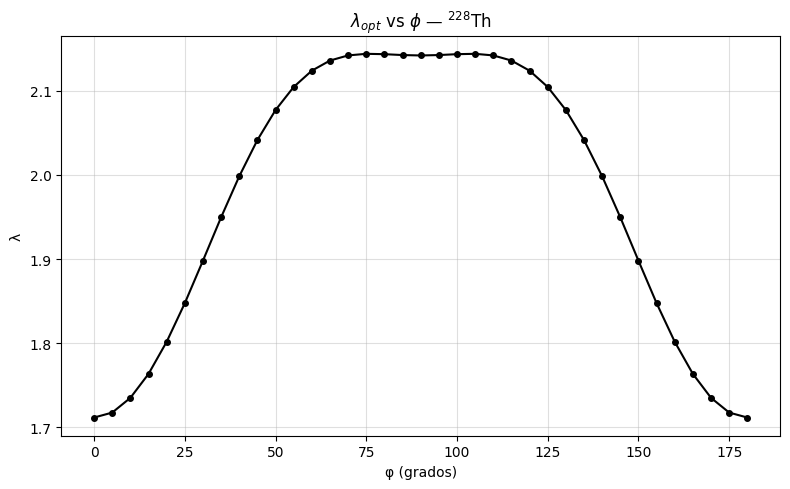

In [5]:
# Prove integral with decay 228-Th 
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, simpson, dblquad
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.optimize import brentq

# ─── Constantes ───────────────────────────────────────────────────────────────
Z_alpha    = 2
Z_daugther = 88
e2         = 1.44
a_0        = 0.54
alpha      = 0.7024
beta       = 0.22
A_alpha    = 4
A_daugther = 224
x          = 7999 / 4
y          = 2134 / 2.5
R_0        = 1.07 * (A_daugther) ** (1 / 3)
beta2      = 0.164
beta4      = 0.112
J00        = -275
Q_alpha    = 5.520
hbarc      = 197.327
L          = 0
G          = 22
B          = (G - L + 1) * (np.pi / 2)
m_n        = 931.5
muc2       = (A_daugther * A_alpha) / (A_daugther + A_alpha) * m_n
zpb        = (muc2 * (beta) ** 2) / (2 * (hbarc) ** 2)

# ─── Armónicos esféricos y geometría de la hija ──────────────────────────────
def Y00(theta): return np.sqrt(1 / (4 * np.pi))
def Y20(theta): return (1 / 4) * np.sqrt(5 / np.pi) * (3 * np.cos(theta) ** 2 - 1)
def Y40(theta): return (3 / 16) * np.sqrt(1 / np.pi) * (35 * np.cos(theta) ** 4 - 30 * np.cos(theta) ** 2 + 3)

def R_f_theta(theta):
    return R_0 * (1 + beta2 * Y20(theta) + beta4 * Y40(theta))

def a_f_theta(theta):
    a_perp = a_0 * (1 + beta2 * Y20(theta) + beta4 * Y40(theta))
    gradR  = (R_0 / R_f_theta(theta)) * (
        -(3 / 2) * np.sqrt(5 / np.pi) * beta2 * np.cos(theta) * np.sin(theta)
        - (105 / 4) * np.sqrt(1 / np.pi) * beta4 * np.cos(theta) ** 3 * np.sin(theta)
        + (45  / 4) * np.sqrt(1 / np.pi) * beta4 * np.cos(theta) * np.sin(theta)
    )
    return a_perp * np.sqrt(1 + np.abs(gradR) ** 2)

# ─── Grillas ─────────────────────────────────────────────────────────────────
rmalla = np.linspace(0.01, 25, 500)
theta  = np.linspace(0, np.pi, 250)
r2, Theta = np.meshgrid(rmalla, theta, indexing='ij')   # (r, θ)

k = np.linspace(0.001, 25, 400)
R = np.linspace(0.05, 30, 800)
phi = np.linspace(0, np.pi, 37)

# Densidad de Fermi (grilla r×θ) — calculada una sola vez
fermi_2D = 1.0 / (1.0 + np.exp((r2 - R_f_theta(Theta)) / a_f_theta(Theta)))

# ─── Funciones de Bessel esféricas ───────────────────────────────────────────
# Versión vectorizada (soporta arrays 2-D)
def j0_f(x): return np.sin(x) / x
def j2_f(x): return (3 / x**2 - 1) * np.sin(x) / x - 3 * np.cos(x) / x**2
def j4_f(x): return ((105 / x**5) - (45 / x**3) + (1 / x)) * np.sin(x) - ((105 / x**4) - (10 / x**2)) * np.cos(x)

# ─── Normalización densidad nuclear hija ─────────────────────────────────────
def rho2_integrand(theta, r):
    return (1 / (1 + np.exp((r - R_f_theta(theta)) / a_f_theta(theta)))) * r**2 * np.sin(theta)

I_rho2, _ = dblquad(rho2_integrand, 0.01, 15, 0, np.pi)
rho2_norm        = A_daugther / (2 * np.pi * I_rho2)
rho2_norm_coulomb = Z_daugther / (2 * np.pi * I_rho2)   # misma integral geométrica

# ─── Transformadas de Fourier de ρ₂ (vectorizadas) ──────────────────────────
# Grilla para la integración: r(eje 0), θ(eje 1), k(eje 2)
# Se construye una vez y se usa para los seis momentos (L=0,2,4 × nuclear/Coulomb)

r3   = rmalla[:, None, None]          # (r, 1, 1)
Th3  = theta[None, :, None]           # (1, θ, 1)
k3   = k[None, None, :]              # (1, 1, k)

fermi_3D = 1.0 / (1.0 + np.exp((r3 - R_f_theta(Th3)) / a_f_theta(Th3)))
sin_Th   = np.sin(Th3)

def fourier_rho2(norm, Ylm, jl, factor_4pi):
    # integrand shape: (r, θ, k)
    integrand = 2 * np.pi * norm * jl(r3 * k3) * Ylm(Th3) * r3**2 * sin_Th * fermi_3D
    int_r  = simpson(integrand, x=rmalla, axis=0)   # (θ, k)
    return simpson(int_r, x=theta, axis=0)           # (k,)

# jl evaluados sobre la grilla r×k
rho2_fn0 = fourier_rho2(rho2_norm,         Y00, j0_f, 1)
rho2_fn2 = fourier_rho2(rho2_norm,         Y20, j2_f, 1)
rho2_fn4 = fourier_rho2(rho2_norm,         Y40, j4_f, 1)

rho2_fc0 = fourier_rho2(rho2_norm_coulomb, Y00, j0_f, 1)
rho2_fc2 = fourier_rho2(rho2_norm_coulomb, Y20, j2_f, 1)
rho2_fc4 = fourier_rho2(rho2_norm_coulomb, Y40, j4_f, 1)

# ─── Transformadas de Fourier de ρ₁ (alfa — analíticas) ─────────────────────
I_r1, _         = quad(lambda r1: r1**2 * np.exp(-alpha * r1**2), 0, 15)
rho1_norm_c     = Z_alpha / (4 * np.pi * I_r1)
gauss_k         = np.exp(-k**2 / (4 * alpha))

rho1_fn = 0.4228 * (np.pi / alpha) ** 1.5 * gauss_k                       # nuclear
rho1_fc = rho1_norm_c * (np.pi / alpha) ** 1.5 * gauss_k                  # Coulomb

# ─── Potencial nuclear — integración en k vectorizada ────────────────────────
# V(R) = (2/π) · prefactor · ∫ ρ₁(k)·ρ₂L(k)·jL(kR)·k²·g(k) dk
# Grilla R×k:
Rm, km = np.meshgrid(R, k, indexing='ij')   # (R, k)
g_k    = x / (k**2 + 4**2) - y / (k**2 + 2.5**2)

def V_nuclear_L(rho1, rho2_fL, jLN, prefactor):
    integrand = prefactor * rho1[None, :] * rho2_fL[None, :] * jLN(Rm * km) * km**2 * (4 * np.pi * g_k[None, :])
    return (2 / np.pi) * simpson(integrand, x=k, axis=1)   # (R,)

V_NN0 = V_nuclear_L(rho1_fn, rho2_fn0, j0_f, 1 / np.sqrt(4 * np.pi))
V_NN2 = V_nuclear_L(rho1_fn, rho2_fn2, j2_f, np.sqrt(5 / (4 * np.pi)))
V_NN4 = V_nuclear_L(rho1_fn, rho2_fn4, j4_f, np.sqrt(9 / (4 * np.pi)))

# ─── Potencial Coulomb — integración en k vectorizada ────────────────────────
def V_coulomb_L(rho1, rho2_fL, jLN, prefactor):
    integrand = prefactor * rho1[None, :] * rho2_fL[None, :] * jLN(Rm * km)
    return (2 * e2 / np.pi) * simpson(integrand, x=k, axis=1)

V_C0 = V_coulomb_L(rho1_fc, rho2_fc0, j0_f, 4 * np.pi / np.sqrt(4 * np.pi))
V_C2 = V_coulomb_L(rho1_fc, rho2_fc2, j2_f, 4 * np.pi * np.sqrt(5  / (4 * np.pi)))
V_C4 = V_coulomb_L(rho1_fc, rho2_fc4, j4_f, 4 * np.pi * np.sqrt(9  / (4 * np.pi)))

# ─── Polinomios de Legendre y ensamble final ──────────────────────────────────
def P2(phi): return 0.5 * (3 * np.cos(phi)**2 - 1)
def P4(phi): return (1 / 8) * (35 * np.cos(phi)**4 - 30 * np.cos(phi)**2 + 3)

# Potencial nuclear total: (R, φ)
V_Nuclear = (
    V_NN0[:, None]
    + V_NN2[:, None] * P2(phi)[None, :]
    + V_NN4[:, None] * P4(phi)[None, :]
)

# Potencial Coulomb total: (R, φ)
V_Coulomb = (
    V_C0[:, None]
    + V_C2[:, None] * P2(phi)[None, :]
    + V_C4[:, None] * P4(phi)[None, :]
)

# ─── Potencial centrífugo ─────────────────────────────────────────────────────
V_L = (hbarc**2 / (2 * muc2)) * ((L + 0.5)**2 / R**2)

def accion_phi_lam(lam, phi_idx):
    V_total = lam * V_Nuclear[:, phi_idx] + V_Coulomb[:, phi_idx] + V_L
    s = InterpolatedUnivariateSpline(R, Q_alpha - V_total, k=3)
    roots = s.roots()
    if len(roots) < 2:
        return None
    r1, r2 = roots[0], roots[-1]
    f = lambda r: np.sqrt(np.abs((2 * muc2 / hbarc**2) * s(r)))
    return quad(f, r1, r2, limit=200)[0]

lam_opt_vs_phi = []

for i, ph in enumerate(phi):
    try:
        # brentq encuentra el lambda donde S(λ) - B = 0
        lam_opt_i = brentq(
            lambda lam: accion_phi_lam(lam, i) - B,
            a=0.5, b=3.0,
            xtol=1e-4
        )
        lam_opt_vs_phi.append((ph, lam_opt_i))
        print(f"φ = {np.degrees(ph):6.1f}°  →  λ = {lam_opt_i:.4f}")
    except (ValueError, TypeError):
        lam_opt_vs_phi.append((ph, None))
        print(f"φ = {np.degrees(ph):6.1f}°  →  sin solución")


phi_arr = np.array([p for p, l in lam_opt_vs_phi if l is not None])
lam_arr = np.array([l for p, l in lam_opt_vs_phi if l is not None])
print('lambda promedio = ',np.around(np.sum(lam_arr)/37,2))

plt.figure(figsize=(8, 5))
plt.plot(np.degrees(phi_arr), lam_arr, 'o-', markersize=4, color='black')
plt.xlabel("φ (grados)")
plt.ylabel("λ")
plt.title(r"$\lambda_{opt}$ vs $\phi$ — $^{228}$Th")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()